In [1]:
import json, glob
import pandas as pd

files = glob.glob("finetune_outputs/*.json")  # adjust pattern

records = []
for f in files:
    with open(f) as fh:
        records.append(json.load(fh))

# ---- 1. One row per run (summary) ----
summary = pd.json_normalize(records)[[
    "training_config.dataset",
    "training_config.label_fraction",
    "training_config.mode",
    "training_config.seed",
    "training_config.lr",
    "evaluation_metrics.test_acc_top1",
    "evaluation_metrics.test_acc_top5",
    "evaluation_metrics.test_loss",
    "training_metrics.best_val_acc",
    "training_metrics.best_epoch",
    "architecture",
]].rename(columns=lambda c: c.split(".")[-1])  # strip prefixes

summary = summary.sort_values("test_acc_top1", ascending=False).reset_index(drop=True)

# ---- 2. One row per epoch per run (curves) ----
curves = []
for d in records:
    tm, cfg = d["training_metrics"], d["training_config"]
    n = len(tm["train_loss"])
    run_id = f"{cfg['dataset']}_frac{cfg['label_fraction']}_seed{cfg['seed']}"
    curves.append(pd.DataFrame({
        "run_id": run_id,
        "epoch": range(n),
        "train_loss": tm["train_loss"],
        "val_loss": tm["val_loss"],
        "train_acc": tm["train_acc"],
        "val_acc": tm["val_acc"],
        "seed": cfg["seed"],
        "label_fraction": cfg["label_fraction"],
    }))
curves = pd.concat(curves, ignore_index=True)

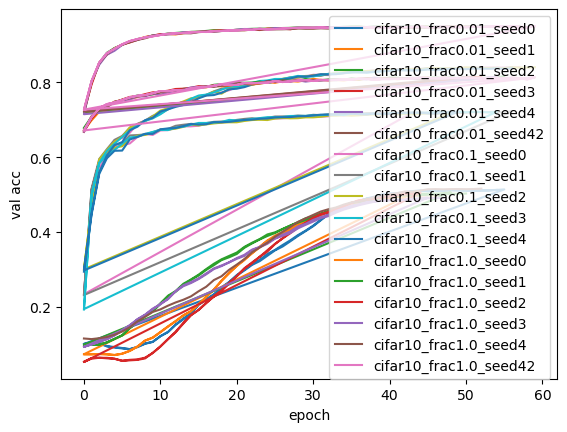

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
for run_id, g in curves.groupby("run_id"):
    ax.plot(g["epoch"], g["val_acc"], label=run_id)
ax.set_xlabel("epoch"); ax.set_ylabel("val acc"); ax.legend()
plt.show()

dataset  label_fraction        mode  n_seeds  test_acc_top1_mean  test_acc_top1_std  test_acc_top5_mean  test_loss_mean  best_val_acc_mean  best_val_acc_std
cifar10            1.00        full        7            0.949586           0.000636            0.999471        0.145672           0.950229          0.000716
cifar10            0.10        full        5            0.839240           0.001705            0.993180        0.538713           0.839720          0.001869
cifar10            1.00 linear_eval        7            0.808743           0.000890            0.992129        0.578307           0.814343          0.000936
cifar10            0.10 linear_eval        5            0.719860           0.001565            0.980220        0.989342           0.721200          0.001838
cifar10            0.01        full        6            0.511733           0.007740            0.929433        2.076988           0.506333          0.008524
cifar10            0.01 linear_eval        5            0.

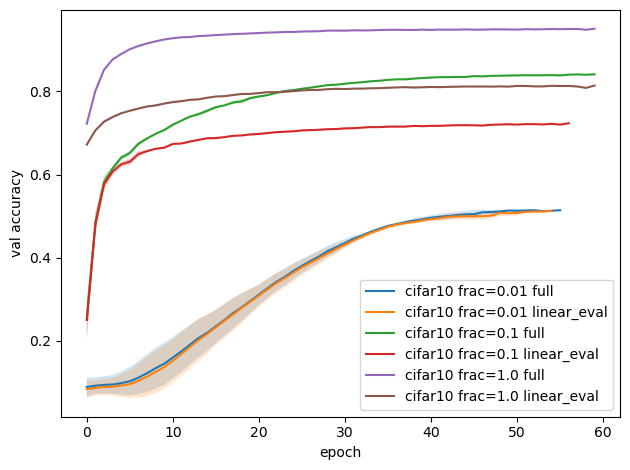

In [3]:
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. Load every run's JSON
# ---------------------------------------------------------------------------
files = glob.glob("finetune_outputs/*.json")  # adjust to your path/pattern

records = []
for f in files:
    with open(f) as fh:
        records.append(json.load(fh))

# ---------------------------------------------------------------------------
# 2. One row per run (flatten scalars, strip dotted prefixes)
# ---------------------------------------------------------------------------
summary = pd.json_normalize(records)[[
    "training_config.dataset",
    "training_config.label_fraction",
    "training_config.mode",
    "training_config.seed",
    "training_config.lr",
    "evaluation_metrics.test_acc_top1",
    "evaluation_metrics.test_acc_top5",
    "evaluation_metrics.test_loss",
    "training_metrics.best_val_acc",
    "training_metrics.best_epoch",
    "architecture",
]].rename(columns=lambda c: c.split(".")[-1])

# ---------------------------------------------------------------------------
# 3. Average across seeds, grouped by dataset / label_fraction / mode
# ---------------------------------------------------------------------------
agg = (
    summary
    .groupby(["dataset", "label_fraction", "mode"], as_index=False)
    .agg(
        n_seeds=("seed", "count"),
        test_acc_top1_mean=("test_acc_top1", "mean"),
        test_acc_top1_std=("test_acc_top1", "std"),
        test_acc_top5_mean=("test_acc_top5", "mean"),
        test_loss_mean=("test_loss", "mean"),
        best_val_acc_mean=("best_val_acc", "mean"),
        best_val_acc_std=("best_val_acc", "std"),
    )
    .sort_values("test_acc_top1_mean", ascending=False)
    .reset_index(drop=True)
)

print(agg.to_string(index=False))

# ---------------------------------------------------------------------------
# 4. (Optional) per-epoch curves, long format, with seed-averaged bands
# ---------------------------------------------------------------------------
curves = []
for d in records:
    tm, cfg = d["training_metrics"], d["training_config"]
    n = len(tm["train_loss"])
    curves.append(pd.DataFrame({
        "dataset": cfg["dataset"],
        "label_fraction": cfg["label_fraction"],
        "mode": cfg["mode"],
        "seed": cfg["seed"],
        "epoch": range(n),
        "train_loss": tm["train_loss"],
        "val_loss": tm["val_loss"],
        "train_acc": tm["train_acc"],
        "val_acc": tm["val_acc"],
    }))
curves = pd.concat(curves, ignore_index=True)

curve_agg = (
    curves
    .groupby(["dataset", "label_fraction", "mode", "epoch"], as_index=False)
    .agg(
        val_acc_mean=("val_acc", "mean"),
        val_acc_std=("val_acc", "std"),
    )
)

fig, ax = plt.subplots()
for (ds, frac, mode), g in curve_agg.groupby(["dataset", "label_fraction", "mode"]):
    label = f"{ds} frac={frac} {mode}"
    ax.plot(g["epoch"], g["val_acc_mean"], label=label)
    ax.fill_between(
        g["epoch"],
        g["val_acc_mean"] - g["val_acc_std"].fillna(0),
        g["val_acc_mean"] + g["val_acc_std"].fillna(0),
        alpha=0.2,
    )
ax.set_xlabel("epoch")
ax.set_ylabel("val accuracy")
ax.legend()
plt.tight_layout()
plt.show()

dataset  label_fraction        mode  n_seeds  test_acc_top1_mean  test_acc_top1_std  test_acc_top5_mean  test_loss_mean  best_val_acc_mean  best_val_acc_std
eurosat             1.0        full        5            0.945444           0.001850            0.999778        0.158063           0.959537          0.000902
eurosat             1.0 linear_eval        5            0.899407           0.001638            0.998704        0.337544           0.910278          0.001617
eurosat             0.1        full        5            0.849296           0.003558            0.996148        0.613798           0.856296          0.001590
eurosat             0.1 linear_eval        5            0.810556           0.002693            0.996000        0.802791           0.826944          0.002502


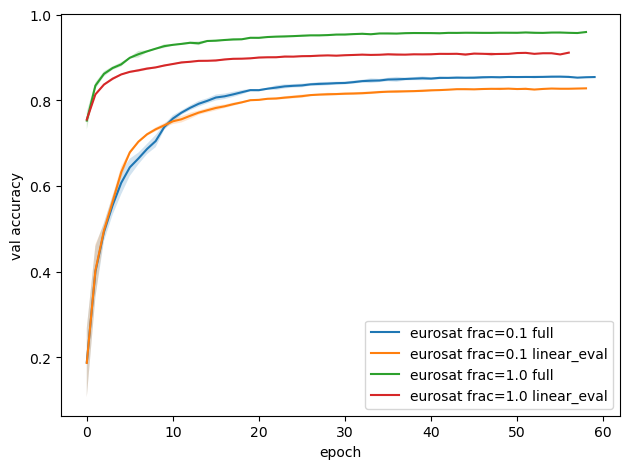

In [4]:
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. Load every run's JSON
# ---------------------------------------------------------------------------
files = glob.glob("eurosat_models/*.json")  # adjust to your path/pattern

records = []
for f in files:
    with open(f) as fh:
        records.append(json.load(fh))

# ---------------------------------------------------------------------------
# 2. One row per run (flatten scalars, strip dotted prefixes)
# ---------------------------------------------------------------------------
summary = pd.json_normalize(records)[[
    "training_config.dataset",
    "training_config.label_fraction",
    "training_config.mode",
    "training_config.seed",
    "training_config.lr",
    "evaluation_metrics.test_acc_top1",
    "evaluation_metrics.test_acc_top5",
    "evaluation_metrics.test_loss",
    "training_metrics.best_val_acc",
    "training_metrics.best_epoch",
    "architecture",
]].rename(columns=lambda c: c.split(".")[-1])

# ---------------------------------------------------------------------------
# 3. Average across seeds, grouped by dataset / label_fraction / mode
# ---------------------------------------------------------------------------
agg = (
    summary
    .groupby(["dataset", "label_fraction", "mode"], as_index=False)
    .agg(
        n_seeds=("seed", "count"),
        test_acc_top1_mean=("test_acc_top1", "mean"),
        test_acc_top1_std=("test_acc_top1", "std"),
        test_acc_top5_mean=("test_acc_top5", "mean"),
        test_loss_mean=("test_loss", "mean"),
        best_val_acc_mean=("best_val_acc", "mean"),
        best_val_acc_std=("best_val_acc", "std"),
    )
    .sort_values("test_acc_top1_mean", ascending=False)
    .reset_index(drop=True)
)

print(agg.to_string(index=False))

# ---------------------------------------------------------------------------
# 4. (Optional) per-epoch curves, long format, with seed-averaged bands
# ---------------------------------------------------------------------------
curves = []
for d in records:
    tm, cfg = d["training_metrics"], d["training_config"]
    n = len(tm["train_loss"])
    curves.append(pd.DataFrame({
        "dataset": cfg["dataset"],
        "label_fraction": cfg["label_fraction"],
        "mode": cfg["mode"],
        "seed": cfg["seed"],
        "epoch": range(n),
        "train_loss": tm["train_loss"],
        "val_loss": tm["val_loss"],
        "train_acc": tm["train_acc"],
        "val_acc": tm["val_acc"],
    }))
curves = pd.concat(curves, ignore_index=True)

curve_agg = (
    curves
    .groupby(["dataset", "label_fraction", "mode", "epoch"], as_index=False)
    .agg(
        val_acc_mean=("val_acc", "mean"),
        val_acc_std=("val_acc", "std"),
    )
)

fig, ax = plt.subplots()
for (ds, frac, mode), g in curve_agg.groupby(["dataset", "label_fraction", "mode"]):
    label = f"{ds} frac={frac} {mode}"
    ax.plot(g["epoch"], g["val_acc_mean"], label=label)
    ax.fill_between(
        g["epoch"],
        g["val_acc_mean"] - g["val_acc_std"].fillna(0),
        g["val_acc_mean"] + g["val_acc_std"].fillna(0),
        alpha=0.2,
    )
ax.set_xlabel("epoch")
ax.set_ylabel("val accuracy")
ax.legend()
plt.tight_layout()
plt.show()